# Statistical Process Control of Coating Thickness Across Production Lines with PROC BOXPLOT

## Executive Summary

This notebook uses **PROC BOXPLOT** to perform statistical process control (SPC) on a critical-to-quality coating thickness measurement collected across four parallel production lines. We generate synthetic measurement data inline (519 parts), profile the lines with `PROC MEANS`, and draw box-and-whisker plots that compare location, spread, and tails across the lines on a single chart.

We then assess each line against the engineering specification (target 50.00 mm, limits 49.80-50.20 mm) directly from the **`OUTBOX=`** statistics dataset -- the exact quartiles, whisker endpoints, mean, and standard deviation behind every box -- and finally demonstrate the **`OUTHISTORY=` / `HISTORY=`** round-trip: PROC BOXPLOT exports one compact summary row per line, and a second PROC BOXPLOT reconstructs the chart straight from that summary, the pattern a daily SPC dashboard uses to re-plot without re-scanning raw measurements.

Across the four lines, **LINE-A is the only line fully within specification** (mean 49.998 mm, well centered on the 50.00 mm target). The other three each violate a spec limit: **LINE-B runs high and is the most variable** (mean 50.062 mm, std 0.078 mm) and carries a cluster of high excursions whose maximum (50.360 mm) is the single worst breach of the 50.20 mm USL; **LINE-D also runs high** (mean 50.115 mm, std 0.084 mm, max 50.312 mm), past the same USL; and **LINE-C runs low** (mean 49.919 mm), with a minimum of 49.771 mm that dips below the 49.80 mm LSL. So three of the four lines are out of specification -- a clear call to action for the shop floor.

## Data Sources

All data is synthetic and generated inline by the first DATA step using `call streaminit(20250531)` and `rand()`. No external or network input is used. The fixed seed makes every number in this notebook reproducible.

**Dataset: `ProcessMeas`** (one row per measured part)

| Variable | Type | Description |
|----------|------|-------------|
| `Line` | Char(6) | Production line identifier: `LINE-A`, `LINE-B`, `LINE-C`, `LINE-D` (the group/classification variable) |
| `Shift` | Num | Production shift index 1-6 (introduces mild between-shift drift) |
| `Thickness` | Num | Coating thickness in mm (the analysis variable); target 50.00 mm, spec limits 49.80-50.20 mm |

Each line is centered at a slightly different mean (50.00 / 50.04 / 49.92 / 50.10) with line-specific variation, mimicking real equipment-to-equipment differences, and `LINE-B` occasionally injects a small positive excursion. The DATA step loops over six shifts and four lines with subgroup sizes of roughly 18-25 parts each, producing **519 parts total** -- **130 / 134 / 136 / 119** for LINE-A through LINE-D, enough to populate four well-defined boxes and to resolve their tails.

# Statistical Process Control of Coating Thickness with PROC BOXPLOT

In high-volume manufacturing, a box-and-whisker plot is the workhorse of shop-floor SPC: it summarizes the central tendency, spread, and outliers of a quality characteristic for each production unit on a single chart. Here we monitor **coating thickness (mm)** on a part produced in parallel on four lines (`LINE-A` through `LINE-D`). The engineering specification is a target of **50.00 mm** with a lower spec limit (LSL) of **49.80 mm** and upper spec limit (USL) of **50.20 mm**.

We will:

1. Generate a synthetic measurement dataset inline.
2. Profile the lines with `PROC MEANS`.
3. Draw the default box plot, then name `BOXSTYLE=SCHEMATIC` explicitly, reading the outlier markers off each chart.
4. Capture every computed box statistic with `OUTBOX=` and assess each line against the spec limits from that table.
5. Persist a compact subgroup summary with `OUTHISTORY=` and exercise the round-trip by re-plotting straight from it with `HISTORY=`.


## Step 1 — Generate synthetic process measurements

The DATA step below simulates measurements over six shifts on four lines. Each line is deliberately centered at a slightly different mean with its own variation, mimicking real equipment-to-equipment differences, and a mild between-shift drift is layered on with a `sin(Shift)` term. A fixed seed (`streaminit(20250531)`) makes every value in the notebook reproducible.

In [1]:
data ProcessMeas;
   call streaminit(20250531);
   length Line $6;
   array lines[4] $6 _temporary_ ('LINE-A' 'LINE-B' 'LINE-C' 'LINE-D');
   array lmean[4]   _temporary_ (50.00 50.04 49.92 50.10);
   array lsd[4]     _temporary_ (0.045 0.060 0.050 0.085);
   label Thickness='Coating Thickness (mm)';
   do Shift = 1 to 6;
      do li = 1 to 4;
         Line = lines[li];
         /* varying subgroup size per line/shift */
         n = 18 + floor(rand('uniform') * 8);
         do u = 1 to n;
            base = lmean[li] + 0.012 * sin(Shift);
            Thickness = base + rand('normal') * lsd[li];
            /* LINE-B injects occasional high excursions */
            if li = 2 and rand('uniform') < 0.05 then
               Thickness = Thickness + rand('uniform') * 0.40;
            Thickness = round(Thickness, 0.001);
            output;
         end;
      end;
   end;
   drop li u n base;
run;

NOTE: DATA ProcessMeas


NOTE: Wrote ProcessMeas (519 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Step 2 — Profile the lines

Before plotting, a quick `PROC MEANS` confirms the data landed as intended: four lines, modest but non-trivial sample sizes, and means clustered near the 50.00 mm target with line-specific spread. This is the numeric backbone the box plot will visualize.

In [2]:
proc means data=ProcessMeas n mean std min max maxdec=3;
   class Line;
   var Thickness;
   title 'Coating Thickness Summary by Production Line';
run;

                                      Coating Thickness Summary by Production Line                                      

                                                  The MEANS Procedure

                                       Analysis Variable : Coating Thickness (mm)

        Line              N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        LINE-A              130         49.998          0.047         49.843         50.099
        LINE-B              134         50.062          0.078         49.921         50.360
        LINE-C              136         49.919          0.052         49.771         50.071
        LINE-D              119         50.115          0.084         49.888         50.312
        -----------------------------------------------------------------------------------



NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Step 3 -- Basic box plot

The simplest invocation needs only the `PLOT analysis-var * group-var` statement. With no `BOXSTYLE=` given, PROC BOXPLOT draws a box per line with whiskers and -- in this engine, whose default style is schematic -- flags any point beyond the 1.5 x IQR fences as an individual outlier marker. The result is a fast visual comparison of location, spread, and extreme parts across `LINE-A` through `LINE-D`. Note immediately the tight cluster of high markers above `LINE-B`: those are the injected excursions that will drive its spec breach.

                                     Skeletal Box Plot of Coating Thickness by Line                                     

                                     Skeletal Box Plot of Coating Thickness by Line

                                                 The BOXPLOT Procedure

Schematic Plots for Coating Thickness (mm)

Line                  N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A              130        49.84        49.97        50.00        50.03        50.10        50.00         0.05
LINE-B              134        49.92        50.01        50.06        50.10        50.36        50.06         0.08
LINE-C              136        49.77        49.88        49.92        49.95        50.07        49.92         0.05
LINE-D              119        49.89        50.06        50.12        50.16        50.31        50.12       

NOTE: Option TITLE changed to Skeletal Box Plot of Coating Thickness by Line.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: ODS plot written: boxplot.spec.json


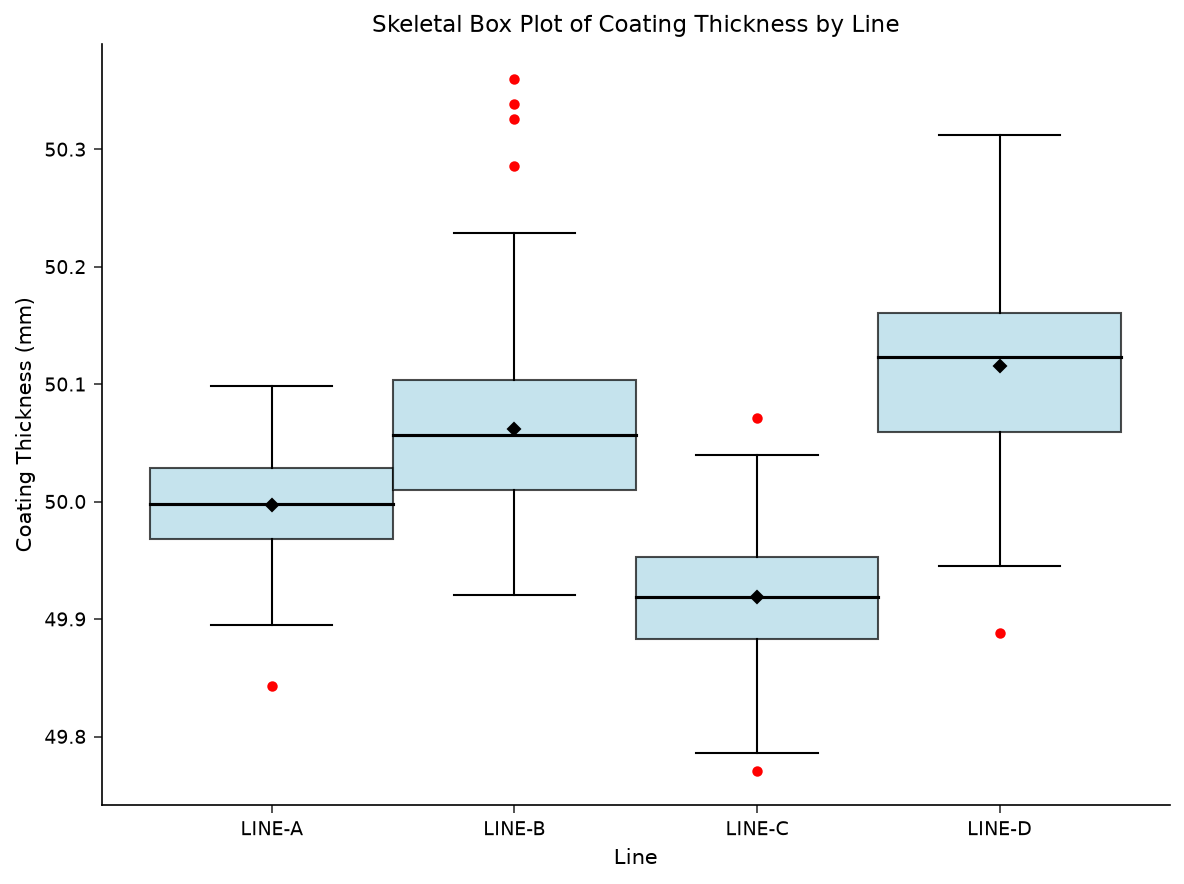

In [3]:
title 'Skeletal Box Plot of Coating Thickness by Line';
proc boxplot data=ProcessMeas;
   plot Thickness*Line;
run;

## Step 4 -- Schematic box plot, stated explicitly

Here we name `BOXSTYLE=SCHEMATIC` outright. In schematic style each whisker is capped at the most extreme observation still inside the 1.5 x IQR fences, and any point beyond a fence is drawn as an individual outlier marker. The chart is the same as Step 3 -- because this engine already defaults to schematic -- but the option makes the choice unambiguous, which matters in a validated SPC program.

The outlier markers tell the real story: **every line has at least one fenced outlier.** `LINE-B` carries four high outliers (the highest at 50.360 mm), `LINE-C` shows both a low and a high outlier, and `LINE-A` and `LINE-D` each have a single low outlier. The process is therefore throwing isolated extreme parts on every line, with `LINE-B` by far the worst -- exactly the kind of signal a schematic box plot exists to surface. Step 5 pins each line against the spec limits.

                                  SPC Schematic Box Plot of Coating Thickness by Line                                   

                                  SPC Schematic Box Plot of Coating Thickness by Line

                                                 The BOXPLOT Procedure

Schematic Plots for Coating Thickness (mm)

Line                  N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A              130        49.84        49.97        50.00        50.03        50.10        50.00         0.05
LINE-B              134        49.92        50.01        50.06        50.10        50.36        50.06         0.08
LINE-C              136        49.77        49.88        49.92        49.95        50.07        49.92         0.05
LINE-D              119        49.89        50.06        50.12        50.16        50.31        50.12     

NOTE: Option TITLE changed to SPC Schematic Box Plot of Coating Thickness by Line.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: ODS plot written: boxplot.spec.json


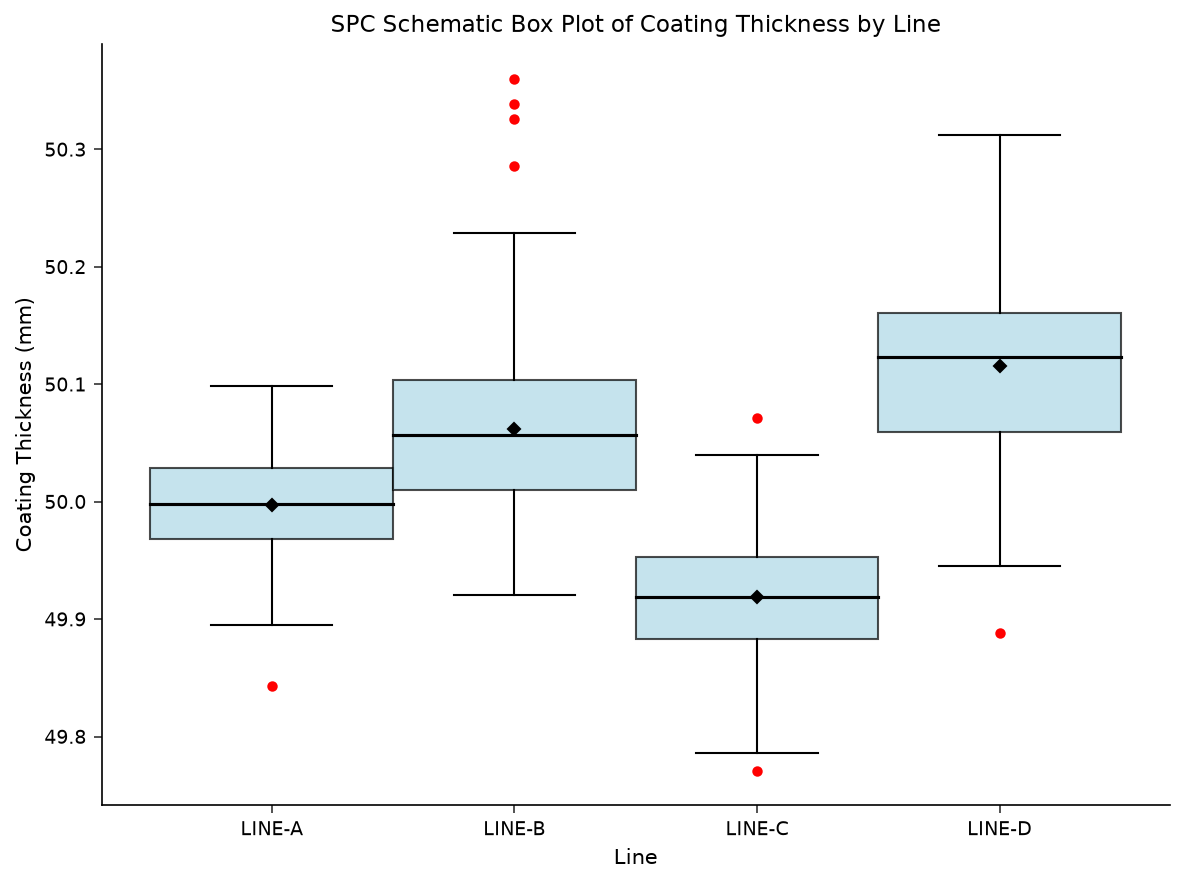

In [4]:
title 'SPC Schematic Box Plot of Coating Thickness by Line';
proc boxplot data=ProcessMeas;
   plot Thickness*Line / boxstyle=schematic;
run;

## Step 5 — Export box statistics and assess against the spec limits

The `OUTBOX=` option captures every computed box statistic to a dataset — for each line: the low whisker (`L`), Q1 (`1`), mean (`X`), median (`M`), Q3 (`3`), high whisker (`H`), standard deviation (`S`), and N. This is the numeric record an auditor needs behind the picture, and it is also the cleanest way to check each line against the 49.80 / 50.20 mm specification. We turn on `GRID` for easier reading, export `BoxStats`, print it, and then run a short DATA step that flags any line whose whisker range pushes past a spec limit.

                                   Schematic Box Plot with Grid and Statistics Export                                   

                                   Schematic Box Plot with Grid and Statistics Export

                                                 The BOXPLOT Procedure

Schematic Plots for Coating Thickness (mm)

Line                  N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A              130        49.84        49.97        50.00        50.03        50.10        50.00         0.05
LINE-B              134        49.92        50.01        50.06        50.10        50.36        50.06         0.08
LINE-C              136        49.77        49.88        49.92        49.95        50.07        49.92         0.05
LINE-D              119        49.89        50.06        50.12        50.16        50.31        50.12     

NOTE: Option TITLE changed to Schematic Box Plot with Grid and Statistics Export.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: Output dataset BOXSTATS created with 4 observations.
NOTE: ODS plot written: boxplot.spec.json
NOTE: Option TITLE changed to Computed Box Statistics (OUTBOX=).
NOTE: PROC PRINT data=BoxStats

NOTE: PROC PRINT completed: 4 observations printed, 9 variables
NOTE: DATA SpecCheck


NOTE: Read 4 rows from BoxStats.
NOTE: Wrote SpecCheck (4 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Spec-Limit Assessment by Line.
NOTE: PROC PRINT data=SpecCheck

NOTE: PROC PRINT completed: 4 observations printed, 6 variables


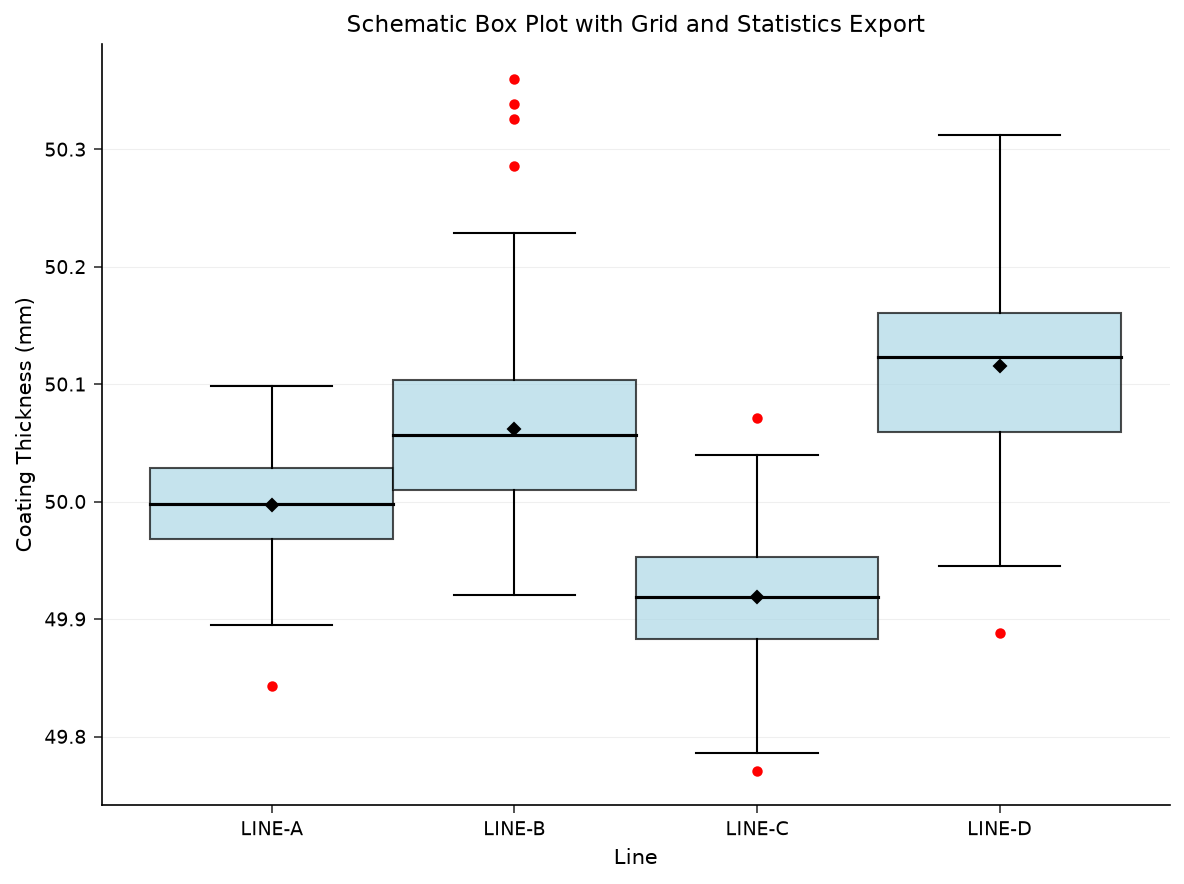

In [5]:
title 'Schematic Box Plot with Grid and Statistics Export';
proc boxplot data=ProcessMeas;
   plot Thickness*Line / boxstyle=schematic
                         grid
                         outbox=BoxStats;
run;

title 'Computed Box Statistics (OUTBOX=)';
proc print data=BoxStats noobs;
run;

/* Assess each line against the 49.80 / 50.20 mm specification    */
/* using the exported whisker endpoints (THICKNESSL = low whisker, */
/* THICKNESSH = high whisker).                                     */
data SpecCheck;
   set BoxStats;
   length Status $40;
   LSL = 49.80;
   USL = 50.20;
   if THICKNESSH > USL then Status = 'High parts exceed USL';
   else if THICKNESSL < LSL then Status = 'Low parts below LSL';
   else Status = 'Within spec';
   keep LINE THICKNESSL THICKNESSH LSL USL Status;
run;

title 'Spec-Limit Assessment by Line';
proc print data=SpecCheck noobs;
run;

## Step 6 — Persist a monitoring history and re-plot from it

In ongoing SPC you rarely re-scan every raw measurement. `OUTHISTORY=` writes one summary row per line (the same layout `HISTORY=` consumes), so the heavy raw data can be archived. Below we export `LineHistory`, print it, and then prove the round-trip by feeding it straight back into a new `PROC BOXPLOT` via `HISTORY=` — exactly how a daily dashboard would reuse pre-aggregated subgroup statistics.

                                                Export Subgroup History                                                 

                                                Export Subgroup History

                                                 The BOXPLOT Procedure

Schematic Plots for Coating Thickness (mm)

Line                  N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A              130        49.84        49.97        50.00        50.03        50.10        50.00         0.05
LINE-B              134        49.92        50.01        50.06        50.10        50.36        50.06         0.08
LINE-C              136        49.77        49.88        49.92        49.95        50.07        49.92         0.05
LINE-D              119        49.89        50.06        50.12        50.16        50.31        50.12         0.08
-----

NOTE: Option TITLE changed to Export Subgroup History.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: Output dataset LINEHISTORY created with 4 observations.
NOTE: ODS plot written: boxplot.spec.json
NOTE: Option TITLE changed to Summary History Dataset (one row per line).
NOTE: PROC PRINT data=LineHistory

NOTE: PROC PRINT completed: 4 observations printed, 9 variables
NOTE: Option TITLE changed to Box Plot Reconstructed from Summary History.
NOTE: PROC BOXPLOT history=LineHistory

NOTE: ODS plot written: boxplot.spec.json


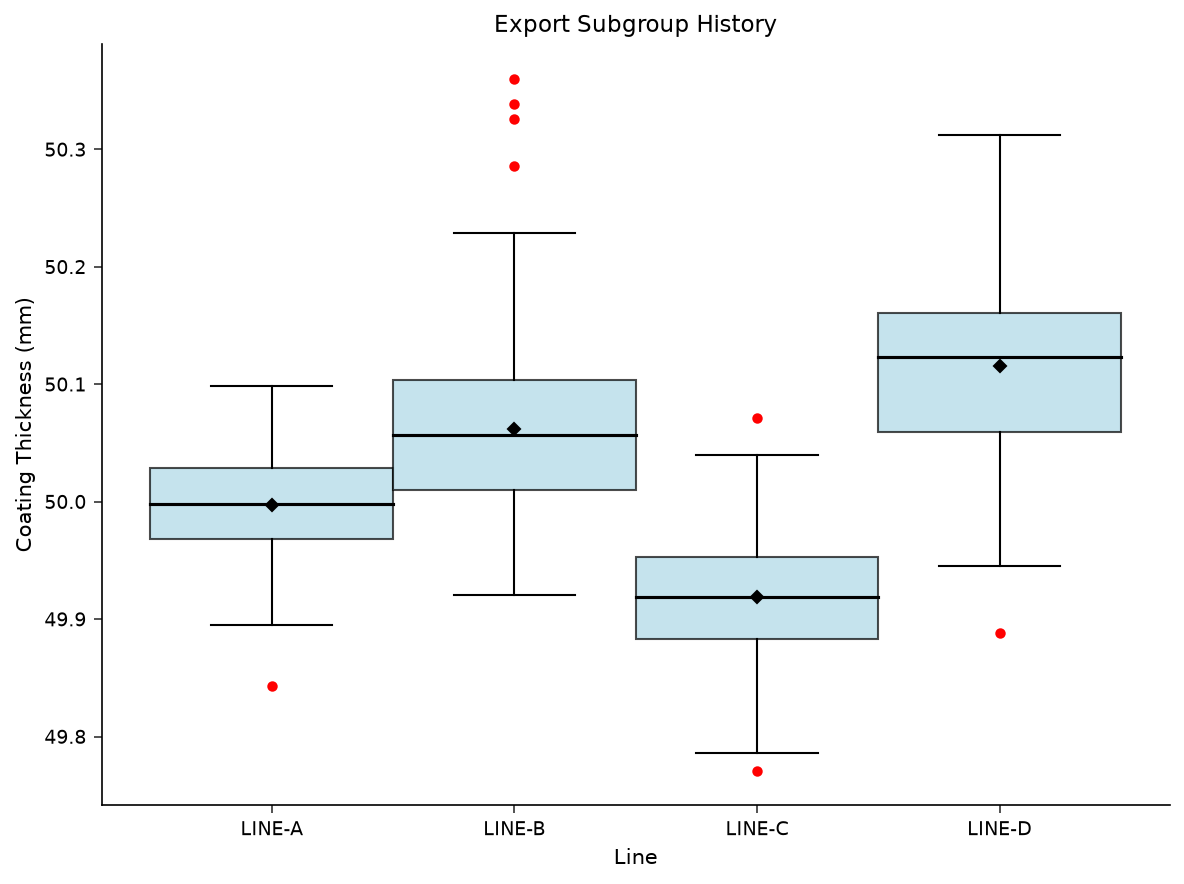

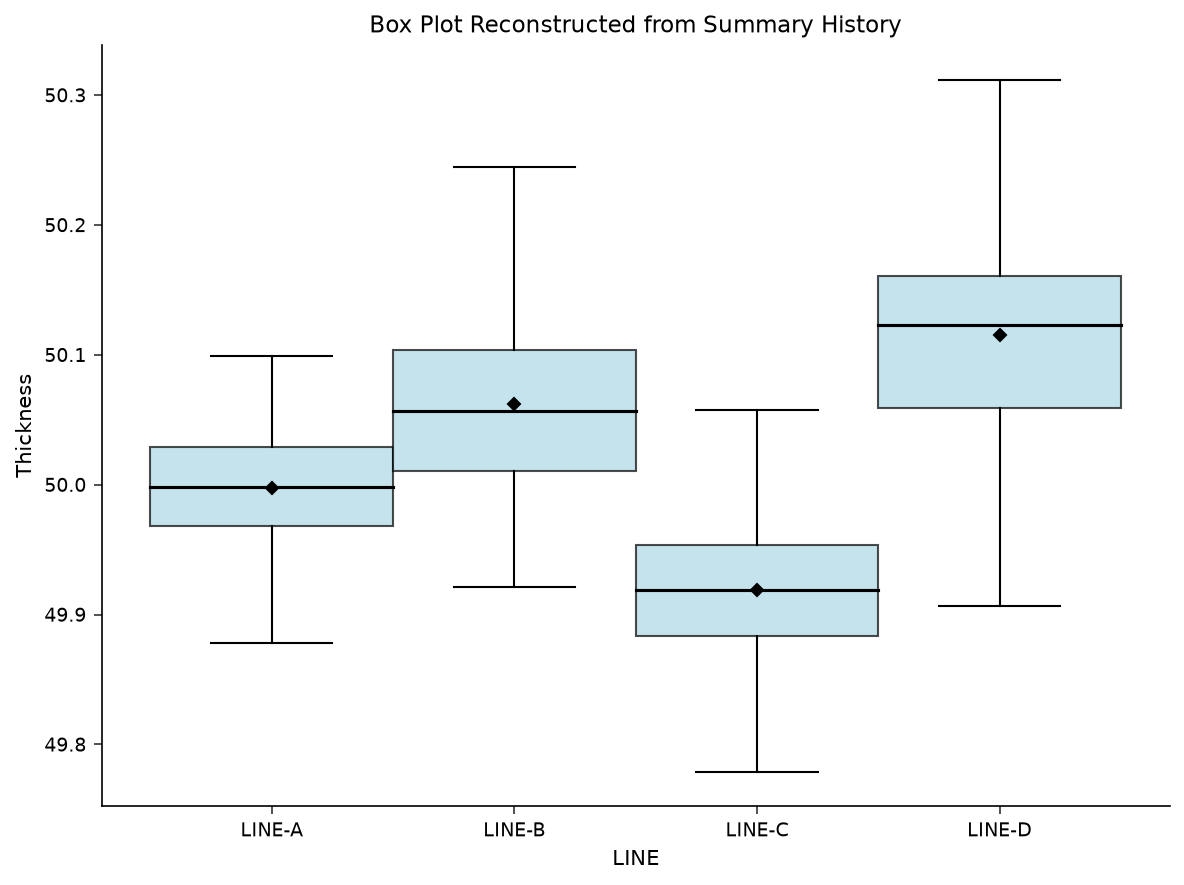

In [6]:
title 'Export Subgroup History';
proc boxplot data=ProcessMeas;
   plot Thickness*Line / outhistory=LineHistory;
run;

title 'Summary History Dataset (one row per line)';
proc print data=LineHistory noobs;
run;

title 'Box Plot Reconstructed from Summary History';
proc boxplot history=LineHistory;
   plot Thickness*Line;
run;

## Interpreting the results

Reading the box plots together with the `PROC MEANS` profile, the `OUTBOX=` table, and the spec-limit assessment:

- **Centering.** `LINE-A` is best centered on the 50.00 mm target (mean 49.998 mm, median 49.998 mm). `LINE-C` runs low (mean 49.919 mm, median 49.919 mm), drifting toward -- and past -- the LSL. `LINE-B` runs high (mean 50.062 mm, median 50.057 mm) and `LINE-D` runs highest (mean 50.115 mm, median 50.123 mm), both pushing toward the USL.
- **Spread.** `LINE-D` and `LINE-B` are the two least stable lines: their standard deviations (0.084 mm and 0.078 mm) are roughly 1.6-1.8x that of the tightest line, `LINE-A` (0.047 mm), with `LINE-C` close behind A at 0.052 mm. The wide `LINE-B` box is inflated by its injected high excursions; the wide `LINE-D` box reflects genuinely larger common-cause variation. Both are candidates for a variation-reduction study.
- **Tails.** In schematic style **every line produces at least one fenced outlier**: `LINE-B` shows four high outliers (topping out at 50.360 mm), `LINE-C` shows a low and a high outlier, and `LINE-A` and `LINE-D` each show a single low outlier. The process is throwing isolated extreme parts on all four lines, most severely on `LINE-B`.
- **Spec conformance.** The `OUTBOX=` whisker endpoints (`THICKNESSL` low, `THICKNESSH` high), assessed against 49.80 / 50.20 mm, leave only `LINE-A` (49.843-50.099 mm) fully **within spec**. The other three each breach a limit: `LINE-B` reaches **50.360 mm** and `LINE-D` reaches **50.312 mm**, both past the **50.20 mm USL**; `LINE-C` dips to **49.771 mm**, below the **49.80 mm LSL**. Three of four lines are out of specification.
- **Operationalization.** The `OUTBOX=` dataset gives auditors the exact quartiles, whisker endpoints, mean, and standard deviation behind the picture, and `OUTHISTORY=` provides a compact one-row-per-line summary (Step 6) so the chart can be regenerated on a schedule without retaining the raw measurements. The chart reconstructed from that summary preserves the boxes, medians, and means but -- because the history dataset stores only summary statistics, not the raw points -- it omits the individual outlier markers and carries a generic `Thickness` axis label rather than the original `Coating Thickness (mm)`. The summary is the right artifact for re-plotting box geometry; the raw data is still required to reproduce the outlier detail.

**Action items:** all three out-of-spec lines need attention. Prioritize `LINE-B` -- chase down the assignable cause behind its high excursions (the four points above 50.20 mm) and reduce its variation; recenter `LINE-D` down toward target and launch a variation-reduction study to pull its high tail inside the USL; nudge `LINE-C` up toward target to lift its low tail back above the LSL. `LINE-A` is the in-control benchmark the other lines should be brought to.